# Keşifsel Veri Analizi (EDA)

**Proje:** ABD Trafik Kazalarında Hava Durumu, Yol Tipi ve Saat Bilgisine
Göre Kaza Şiddetinin Tahmini

Bu notebook, hazırlanmış veri seti üzerinde keşifsel veri analizi yapar:
betimsel istatistikler, değişken dağılımları, değişkenler arası ilişkiler
ve aykırı değer tespiti.

**Girdi:** `temiz_veri.parquet`

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

df = pd.read_parquet("../data/processed/temiz_veri.parquet")

print("Boyut:", df.shape)
print()
print(df.head(3).to_string())

Boyut: (1278270, 47)

         ID  Severity          Start_Time  Start_Lat  Start_Lng                           Street   City        County State     Zipcode    Timezone  Temperature(F)  Humidity(%)  Pressure(in)  Visibility(mi) Wind_Direction  Wind_Speed(mph)  Precipitation(in) Weather_Condition  Amenity   Bump  Crossing  Give_Way  Junction  No_Exit  Railway  Roundabout  Station   Stop  Traffic_Calming  Traffic_Signal Sunrise_Sunset Civil_Twilight Nautical_Twilight Astronomical_Twilight  nufus_2022  nufus_yogunlugu  kentsel_kirsal  saat  gun  ay   yil  hafta_sonu  yogun_saat    mevsim   yol_tipi hava_durumu
0  A-116062         3 2016-11-30 15:36:03  27.981367 -82.326561  E Dr Martin Luther King Jr Blvd  Tampa  Hillsborough    FL       33610  US/Eastern            80.6         70.0         29.94            10.0            SSW              5.8                0.0          Overcast    False  False     False     False     False    False    False       False    False  False            False

## 1. Veriye ilk bakış

Veri setinin boyutu, sütun yapısı ve veri tipleri incelenmiştir.

In [38]:
print("Satır:", f"{df.shape[0]:,}")
print("Sütun:", df.shape[1])
print("Bellek:", f"{df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")
print()

print("Veri tipleri:")
print(df.dtypes.value_counts().to_string())
print()

print("Hedef değişken dağılımı (Severity):")
sev = df["Severity"].value_counts().sort_index()
sev_yuzde = (df["Severity"].value_counts(normalize=True).sort_index() * 100).round(2)
print(pd.DataFrame({"adet": sev, "yuzde": sev_yuzde}).to_string())
print()

print("Eyalet dağılımı:")
print(df["State"].value_counts().to_string())
print()

print("Tarih aralığı:", df["Start_Time"].min(), "→", df["Start_Time"].max())

Satır: 1,278,270
Sütun: 47
Bellek: 441 MB

Veri tipleri:
str               16
bool              14
float64           10
int32              4
int64              2
datetime64[ns]     1

Hedef değişken dağılımı (Severity):
             adet  yuzde
Severity                
1            8452   0.66
2         1044195  81.69
3          201709  15.78
4           23914   1.87

Eyalet dağılımı:
State
FL    783152
NY    316409
MN    178709

Tarih aralığı: 2016-03-23 02:35:03 → 2023-03-31 23:09:00


## 2. Betimsel istatistikler

Sayısal değişkenlerin merkezi eğilim ve yayılım ölçüleri incelenmiştir.

In [39]:
SAYISAL = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
           "Wind_Speed(mph)", "Precipitation(in)", "nufus_yogunlugu", "saat"]

print(df[SAYISAL].describe().T.round(2).to_string())

                       count     mean       std    min     25%      50%      75%       max
Temperature(F)     1278270.0    65.05     20.95 -36.00   55.00    72.00    80.00    118.40
Humidity(%)        1278270.0    70.41     18.23   1.00   57.00    72.00    86.00    100.00
Pressure(in)       1278270.0    29.86      0.40  26.85   29.82    29.98    30.08     30.94
Visibility(mi)     1278270.0     9.19      2.31   0.00   10.00    10.00    10.00     20.00
Wind_Speed(mph)    1278270.0     8.64      5.09   0.00    5.80     8.00    12.00    100.00
Precipitation(in)  1278270.0     0.01      0.19   0.00    0.00     0.00     0.00     10.16
nufus_yogunlugu    1278270.0  4156.15  10824.58   2.97  622.64  1428.15  1634.58  70487.38
saat               1278270.0    12.29      5.39   0.00    8.00    13.00    17.00     23.00


## 3. Aykırı değer analizi

Betimsel istatistiklerde fiziksel olarak imkânsız değerler tespit edilmiştir
(984 mph rüzgâr hızı, 174°F sıcaklık, 105 mil görüş mesafesi, 0 inHg basınç).
Aykırı değerler önce IQR yöntemiyle ölçülmüş, ardından fiziksel sınırlara
göre düzeltilmiştir.

In [40]:
def iqr_aykiri(seri):
    Q1 = seri.quantile(0.25)
    Q3 = seri.quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    aykiri = ((seri < alt) | (seri > ust)).sum()
    return pd.Series({
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "alt_sinir": round(alt, 2),
        "ust_sinir": round(ust, 2),
        "aykiri_sayi": aykiri,
        "aykiri_yuzde": round(aykiri / len(seri) * 100, 2)
    })

SAYISAL = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)",
           "Wind_Speed(mph)", "Precipitation(in)", "nufus_yogunlugu"]

sonuc = pd.DataFrame({s: iqr_aykiri(df[s]) for s in SAYISAL}).T
print(sonuc.to_string())

                       Q1       Q3  alt_sinir  ust_sinir  aykiri_sayi  aykiri_yuzde
Temperature(F)      55.00    80.00      17.50     117.50      43665.0          3.42
Humidity(%)         57.00    86.00      13.50     129.50        361.0          0.03
Pressure(in)        29.82    30.08      29.43      30.47     181161.0         14.17
Visibility(mi)      10.00    10.00      10.00      10.00     202283.0         15.82
Wind_Speed(mph)      5.80    12.00      -3.50      21.30      20696.0          1.62
Precipitation(in)    0.00     0.00       0.00       0.00      95328.0          7.46
nufus_yogunlugu    622.64  1634.58    -895.27    3152.49     193219.0         15.12


### 3.2 Fiziksel sınırlara göre düzeltme

IQR çarpık dağılımlarda yanıltıcı: `Precipitation(in)`'in büyük bölümü sıfır
olduğu için IQR aralığı sıfıra yakın çıkar ve gerçekleşen her yağış aykırı
sayılır. Bu yüzden ölçüt olarak **fiziksel sınırlar** kullanıldı.

Düzeltme **01 § 3.1'de** yapılıyor (sınır dışı ölçüm eksik sayılıp
dolduruluyor, satır silinmiyor). Aşağıdaki hücre veriyi değiştirmez, sadece
doğrular.

In [41]:
# 01 § 3.1'de kullanılan sınırlarla AYNI. Burada veri değiştirilmez, doğrulanır.
SINIRLAR = {
    "Temperature(F)":    (-40, 130),
    "Humidity(%)":       (  0, 100),
    "Pressure(in)":      ( 25,  32),
    "Visibility(mi)":    (  0,  20),
    "Wind_Speed(mph)":   (  0, 100),
    "Precipitation(in)": (  0,  12),
}

print("DOĞRULAMA — 01'in çıktısı fiziksel sınırlar içinde mi?")
ihlal = 0
for sutun, (alt, ust) in SINIRLAR.items():
    disarda = ((df[sutun] < alt) | (df[sutun] > ust)).sum()
    ihlal += disarda
    durum = "✓" if disarda == 0 else "✗"
    print(f"{durum} {sutun:<20} [{alt:>4}, {ust:>4}]  sınır dışı: {disarda:>6,}")

print()
if ihlal == 0:
    print("✓ Tüm ölçümler fiziksel sınırlar içinde — 01'de düzeltilmiş.")
else:
    print(f"✗ {ihlal:,} sınır dışı değer var. 01'i yeniden çalıştırın.")

print()
print("Gerçekleşen min / max değerler:")
print(df[list(SINIRLAR.keys())].describe().T[["min", "max"]].round(2).to_string())

DOĞRULAMA — 01'in çıktısı fiziksel sınırlar içinde mi?
✓ Temperature(F)       [ -40,  130]  sınır dışı:      0
✓ Humidity(%)          [   0,  100]  sınır dışı:      0
✓ Pressure(in)         [  25,   32]  sınır dışı:      0
✓ Visibility(mi)       [   0,   20]  sınır dışı:      0
✓ Wind_Speed(mph)      [   0,  100]  sınır dışı:      0
✓ Precipitation(in)    [   0,   12]  sınır dışı:      0

✓ Tüm ölçümler fiziksel sınırlar içinde — 01'de düzeltilmiş.

Gerçekleşen min / max değerler:
                     min     max
Temperature(F)    -36.00  118.40
Humidity(%)         1.00  100.00
Pressure(in)       26.85   30.94
Visibility(mi)      0.00   20.00
Wind_Speed(mph)     0.00  100.00
Precipitation(in)   0.00   10.16


## 4. Görselleştirme

### 4.1 Hedef değişken dağılımı

Kaza şiddeti sınıflarının dağılımı incelenmiştir. Sınıflar arasındaki
dengesizlik, model değerlendirme metriğinin seçimini doğrudan etkilemektedir.

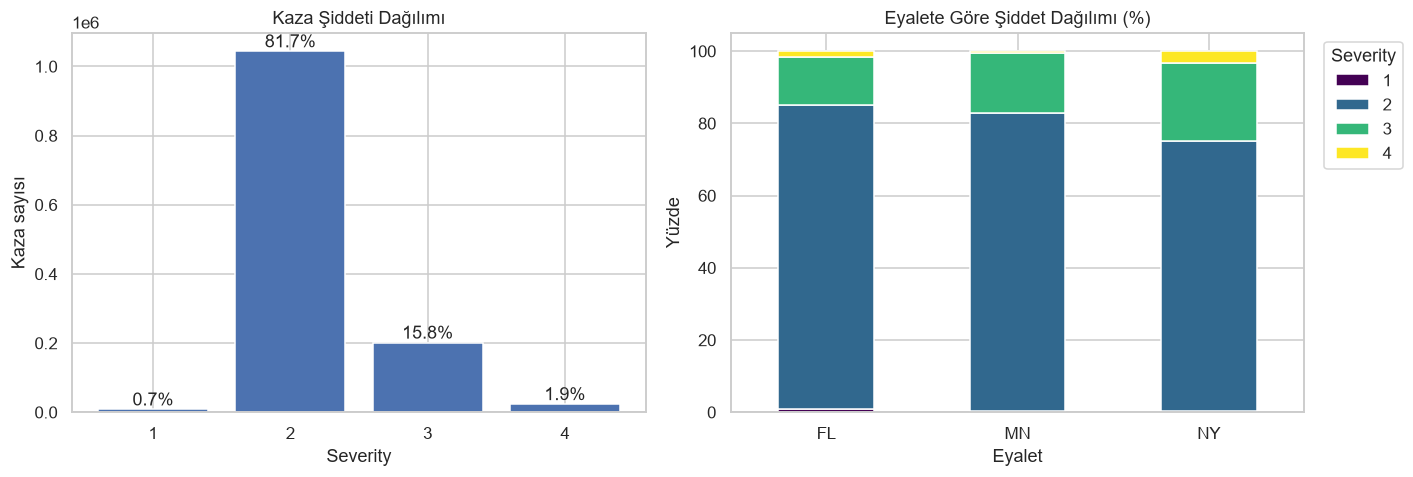

Severity     1      2      3     4
State                             
FL        0.88  84.31  13.18  1.64
MN        0.27  82.57  16.68  0.47
NY        0.35  74.71  21.71  3.24


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: genel dağılım
sev = df["Severity"].value_counts().sort_index()
axes[0].bar(sev.index.astype(str), sev.values, color="#4C72B0")
axes[0].set_title("Kaza Şiddeti Dağılımı")
axes[0].set_xlabel("Severity")
axes[0].set_ylabel("Kaza sayısı")
for i, v in enumerate(sev.values):
    axes[0].text(i, v, f"{v/len(df)*100:.1f}%", ha="center", va="bottom")

# Sağ: eyalet kırılımı (oran)
oran = pd.crosstab(df["State"], df["Severity"], normalize="index") * 100
oran.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Eyalete Göre Şiddet Dağılımı (%)")
axes[1].set_xlabel("Eyalet")
axes[1].set_ylabel("Yüzde")
axes[1].legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(oran.round(2).to_string())

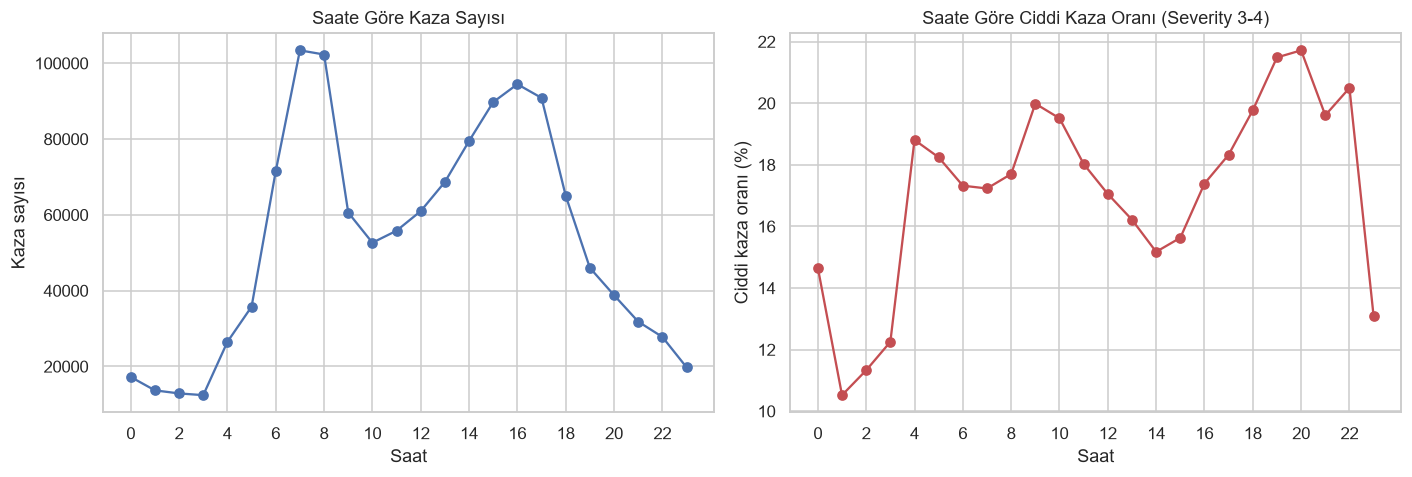

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Sol: saatlik kaza sayısı
saatlik = df["saat"].value_counts().sort_index()
axes[0].plot(saatlik.index, saatlik.values, marker="o", color="#4C72B0")
axes[0].set_title("Saate Göre Kaza Sayısı")
axes[0].set_xlabel("Saat")
axes[0].set_ylabel("Kaza sayısı")
axes[0].set_xticks(range(0, 24, 2))

# Sağ: saate göre ciddi kaza oranı (3+4)
df["ciddi"] = df["Severity"].isin([3, 4])
oran_saat = df.groupby("saat")["ciddi"].mean() * 100
axes[1].plot(oran_saat.index, oran_saat.values, marker="o", color="#C44E52")
axes[1].set_title("Saate Göre Ciddi Kaza Oranı (Severity 3-4)")
axes[1].set_xlabel("Saat")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

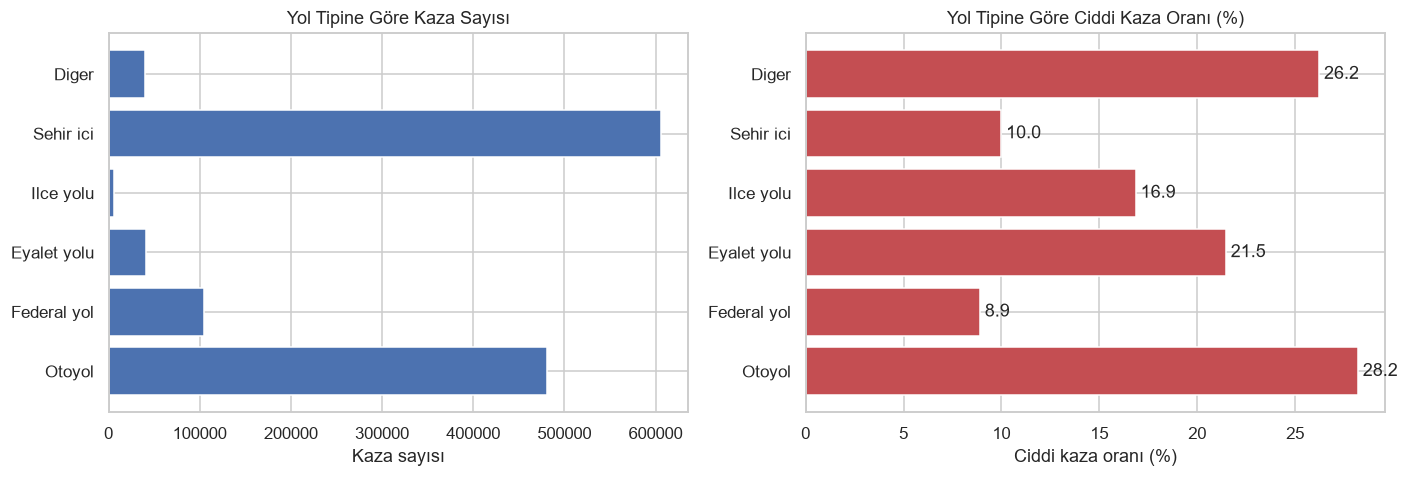

              count  ciddi_yuzde
yol_tipi                        
Otoyol       480646        28.20
Federal yol  105266         8.90
Eyalet yolu   41432        21.46
Ilce yolu      5659        16.86
Sehir ici    605633         9.99
Diger         39634        26.22


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sira = ["Otoyol", "Federal yol", "Eyalet yolu", "Ilce yolu", "Sehir ici", "Diger"]

# Sol: kaza sayısı
sayi = df["yol_tipi"].value_counts().reindex(sira)
axes[0].barh(sayi.index, sayi.values, color="#4C72B0")
axes[0].set_title("Yol Tipine Göre Kaza Sayısı")
axes[0].set_xlabel("Kaza sayısı")

# Sağ: ciddi kaza oranı
oran = (df.groupby("yol_tipi")["ciddi"].mean() * 100).reindex(sira)
axes[1].barh(oran.index, oran.values, color="#C44E52")
axes[1].set_title("Yol Tipine Göre Ciddi Kaza Oranı (%)")
axes[1].set_xlabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran.values):
    axes[1].text(v, i, f" {v:.1f}", va="center")

plt.tight_layout()
plt.show()

print((df.groupby("yol_tipi")["ciddi"].agg(["count", "mean"])
       .assign(ciddi_yuzde=lambda x: (x["mean"]*100).round(2))
       .drop(columns="mean").reindex(sira).to_string()))

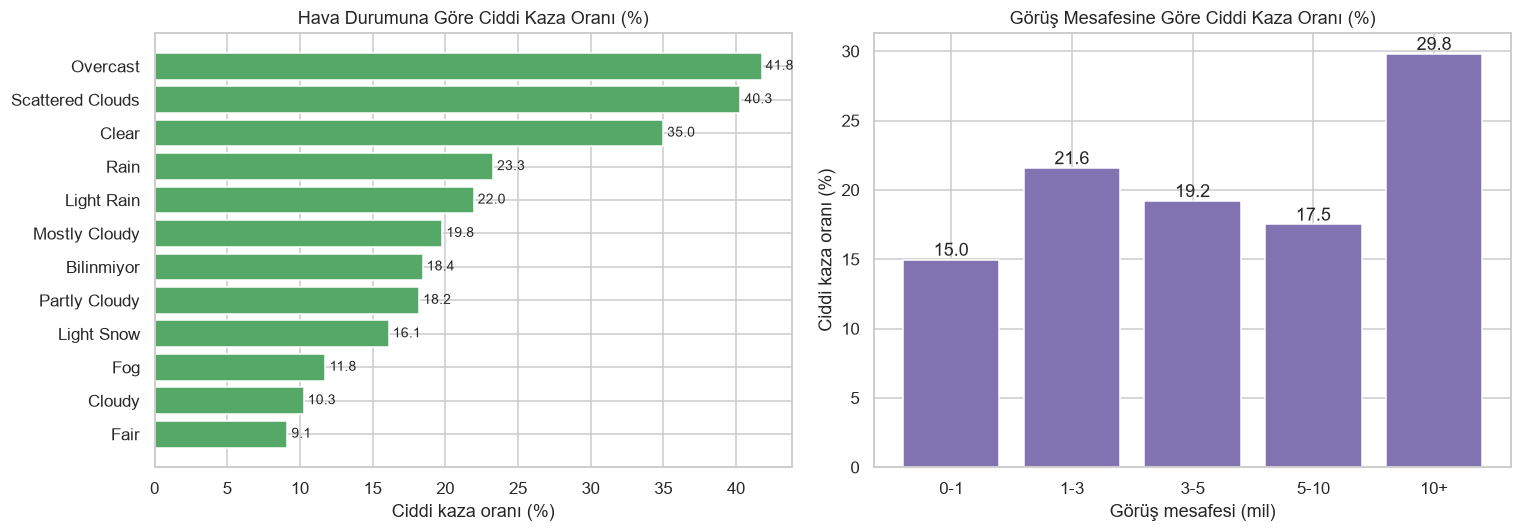

Weather_Condition
Fair                399732
Mostly Cloudy       216869
Partly Cloudy       150916
Cloudy              123390
Clear                94779
Light Rain           55499
Overcast             45853
Scattered Clouds     42277
Light Snow           33541
Bilinmiyor           14371
Fog                  13084
Rain                 10894


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: en sık 12 hava durumu
top12 = df["Weather_Condition"].value_counts().head(12).index
alt = df[df["Weather_Condition"].isin(top12)]
oran_hava = (alt.groupby("Weather_Condition")["ciddi"].mean() * 100).sort_values()

axes[0].barh(oran_hava.index, oran_hava.values, color="#55A868")
axes[0].set_title("Hava Durumuna Göre Ciddi Kaza Oranı (%)")
axes[0].set_xlabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran_hava.values):
    axes[0].text(v, i, f" {v:.1f}", va="center", fontsize=9)

# Sağ: görüş mesafesi
df["gorus_grup"] = pd.cut(df["Visibility(mi)"],
                          bins=[-0.1, 1, 3, 5, 10, 20],
                          labels=["0-1", "1-3", "3-5", "5-10", "10+"])
oran_gorus = df.groupby("gorus_grup", observed=True)["ciddi"].mean() * 100

axes[1].bar(oran_gorus.index.astype(str), oran_gorus.values, color="#8172B2")
axes[1].set_title("Görüş Mesafesine Göre Ciddi Kaza Oranı (%)")
axes[1].set_xlabel("Görüş mesafesi (mil)")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
for i, v in enumerate(oran_gorus.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(df["Weather_Condition"].value_counts().head(12).to_string())

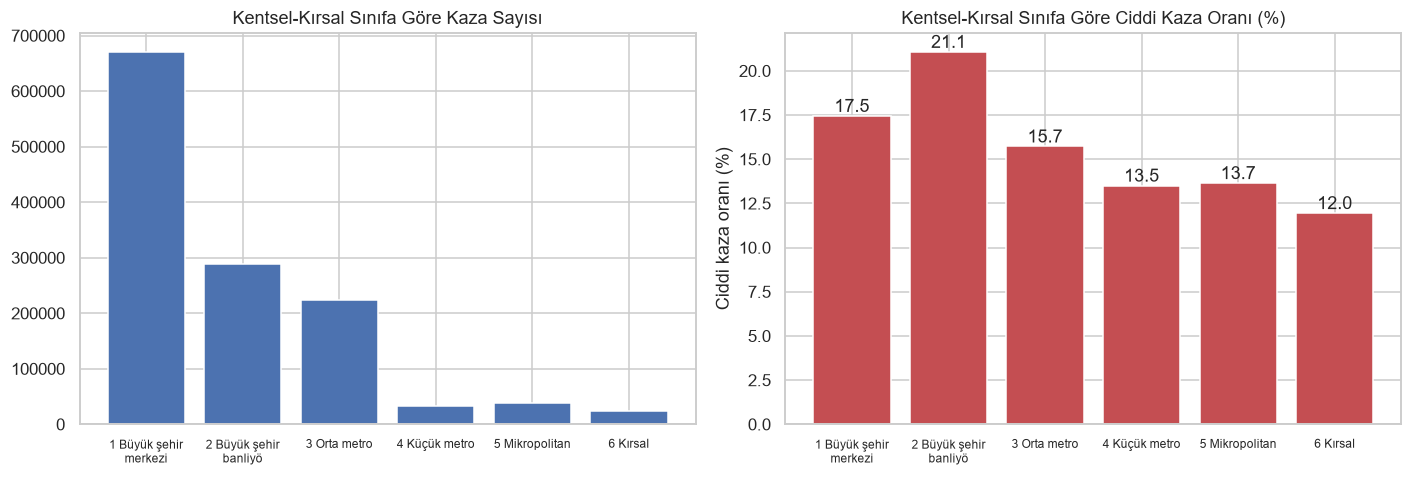

                 count  ciddi_yuzde
kentsel_kirsal                     
1.0             670906        17.45
2.0             288791        21.08
3.0             223165        15.72
4.0              33615        13.51
5.0              37721        13.65
6.0              24072        11.96


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

etiket = {1: "1 Büyük şehir\nmerkezi", 2: "2 Büyük şehir\nbanliyö",
          3: "3 Orta metro", 4: "4 Küçük metro",
          5: "5 Mikropolitan", 6: "6 Kırsal"}

# Sol: kaza sayısı
sayi = df["kentsel_kirsal"].value_counts().sort_index()
axes[0].bar([etiket.get(i, str(i)) for i in sayi.index], sayi.values, color="#4C72B0")
axes[0].set_title("Kentsel-Kırsal Sınıfa Göre Kaza Sayısı")
axes[0].tick_params(axis="x", labelsize=8)

# Sağ: ciddi kaza oranı
oran = (df.groupby("kentsel_kirsal")["ciddi"].mean() * 100).sort_index()
axes[1].bar([etiket.get(i, str(i)) for i in oran.index], oran.values, color="#C44E52")
axes[1].set_title("Kentsel-Kırsal Sınıfa Göre Ciddi Kaza Oranı (%)")
axes[1].set_ylabel("Ciddi kaza oranı (%)")
axes[1].tick_params(axis="x", labelsize=8)
for i, v in enumerate(oran.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(df.groupby("kentsel_kirsal")["ciddi"].agg(["count", "mean"])
      .assign(ciddi_yuzde=lambda x: (x["mean"]*100).round(2))
      .drop(columns="mean").to_string())

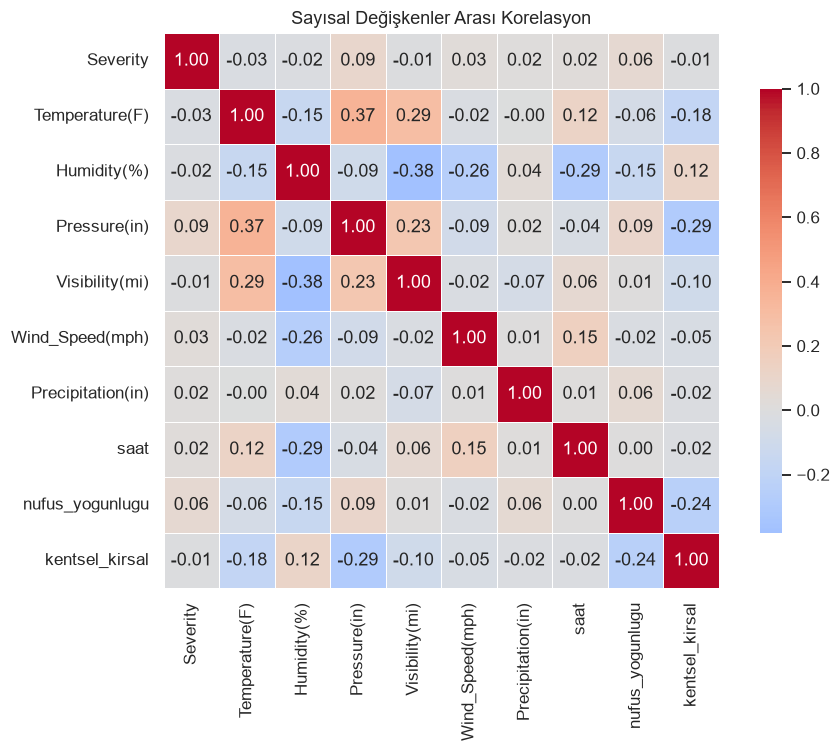

Severity ile korelasyonlar:
Pressure(in)         0.092
nufus_yogunlugu      0.061
Wind_Speed(mph)      0.033
saat                 0.022
Precipitation(in)    0.015
Visibility(mi)      -0.005
kentsel_kirsal      -0.009
Humidity(%)         -0.015
Temperature(F)      -0.025


In [47]:
KORELASYON = ["Severity", "Temperature(F)", "Humidity(%)", "Pressure(in)",
              "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)",
              "saat", "nufus_yogunlugu", "kentsel_kirsal"]

korr = df[KORELASYON].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(korr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.tight_layout()
plt.show()

print("Severity ile korelasyonlar:")
print(korr["Severity"].drop("Severity").sort_values(ascending=False).round(3).to_string())